# Baseline Models — Flight Delay Prediction

Binary classification: predict whether a flight will be delayed ≥ 15 minutes (`DepDel15 = 1`).

## Input
- `data/processed/integrated/features_2024.parquet`

## Models
1. **Logistic Regression** — linear baseline
2. **Random Forest** — non-linear baseline

## Split strategy
- **Train**: January – October 2024 (months 1–10)
- **Test**: November – December 2024 (months 11–12)
- Temporal split prevents future-leaking and simulates real-world deployment.

## Metrics
- Accuracy, Precision, Recall, F1 Score, AUC-ROC

## Step 0: Ensure project data

In [1]:
import sys
from pathlib import Path

_here = Path.cwd().resolve()
for _p in [_here] + list(_here.parents):
    if (_p / "notebooks" / "project_data.py").exists():
        sys.path.insert(0, str(_p / "notebooks"))
        break

from project_data import ensure_project_data

ensure_project_data()

[data] Already present: /Users/jeffvan/Desktop/My Stuff/Courses/CIS5450/CIS-5450/data


PosixPath('/Users/jeffvan/Desktop/My Stuff/Courses/CIS5450/CIS-5450/data')

## Step 1: Load data and select features

In [2]:
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay,
)
from sklearn.preprocessing import StandardScaler

from project_data import resolve_project_root

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = resolve_project_root()
DATA_ROOT = Path(os.getenv("FLIGHT_DATA_DIR", PROJECT_ROOT / "data")).expanduser().resolve()
INTEGRATED_DIR = DATA_ROOT / "processed" / "integrated"
REPORT_DIR = DATA_ROOT / "reports" / "modeling"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(INTEGRATED_DIR / "features_2024.parquet")
df["FlightDate"] = pd.to_datetime(df["FlightDate"])
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")

Loaded 6,817,598 rows, 81 columns


In [3]:
# ── Feature selection ──
# Exclude: target, realized outcomes, identifiers, leakage-prone columns
TARGET = "DepDel15"

LEAKAGE_COLS = [
    # Target and direct encodings
    "DepDel15", "DepDelay", "DepDelayMinutes", "DepTime",
    # Realized arrival info
    "ArrDelay", "ArrDelayMinutes", "ArrDel15", "ArrTime",
    # Realized flight durations
    "ActualElapsedTime", "AirTime", "TaxiOut", "TaxiIn",
    # Post-hoc delay cause attribution (only available after the fact)
    "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay",
    # Already filtered (all 0)
    "Cancelled", "CancellationCode", "Diverted",
]

ID_COLS = ["FlightDate", "Tail_Number", "Flight_Number_Reporting_Airline"]

# Categorical columns that need encoding
CAT_COLS = ["Reporting_Airline", "Origin", "Dest", "time_block", "distance_bin"]

# Numeric features: everything that is not target, leakage, id, or categorical
NUMERIC_FEATURES = [
    # Scheduled info
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
    # Time features
    "dep_hour", "month", "day_of_week", "is_weekend",
    # Holiday
    "is_holiday", "holiday_proximity",
    # Hub
    "is_origin_hub", "is_dest_hub",
    # Rolling historical (shifted, no leakage)
    "airline_delay_rate_7d", "origin_delay_rate_7d", "route_delay_rate_7d",
    "origin_daily_flights",
    # Cascading
    "prev_flight_arr_delay", "tail_leg_today",
    # Congestion
    "origin_hourly_flights",
    # Weather (origin)
    "origin_air_temp", "origin_dew_point", "origin_sea_level_pres",
    "origin_wind_dir", "origin_wind_speed", "origin_sky_cover",
    "origin_precip_1h", "origin_precip_6h",
    "origin_weather_severity",
    "origin_freezing_rain", "origin_wind_rain", "origin_fog_risk",
    # Weather (dest)
    "dest_air_temp", "dest_dew_point", "dest_sea_level_pres",
    "dest_wind_dir", "dest_wind_speed", "dest_sky_cover",
    "dest_precip_1h", "dest_precip_6h",
    "dest_weather_severity",
    "dest_freezing_rain", "dest_wind_rain", "dest_fog_risk",
    # Worst-case
    "worst_precip", "worst_wind",
    # Original binary flags
    "origin_is_rain", "origin_high_wind", "origin_freezing", "origin_low_vis",
    "dest_is_rain", "dest_high_wind", "dest_freezing", "dest_low_vis",
]

print(f"Numeric features: {len(NUMERIC_FEATURES)}")
print(f"Categorical features: {len(CAT_COLS)}")
print(f"Leakage columns excluded: {len(LEAKAGE_COLS)}")

Numeric features: 53
Categorical features: 5
Leakage columns excluded: 20


## Step 2: Temporal train/test split and preprocessing

In [4]:
# ── Temporal split: train on months 1-10, test on months 11-12 ──
train_mask = df["month"] <= 10
test_mask = df["month"] >= 11

y_full_train = df.loc[train_mask, TARGET].astype(int)
y_test = df.loc[test_mask, TARGET].astype(int)

print(f"Full train: {train_mask.sum():,} rows  (months 1-10)")
print(f"Test:       {test_mask.sum():,} rows  (months 11-12)")

# ── Subsample training set for speed (stratified) ──
TRAIN_SAMPLE = 1_000_000
rng = np.random.RandomState(42)
train_idx = df.index[train_mask]

if len(train_idx) > TRAIN_SAMPLE:
    # Stratified subsample to preserve class ratio
    pos_idx = train_idx[y_full_train == 1]
    neg_idx = train_idx[y_full_train == 0]
    ratio = len(pos_idx) / len(train_idx)
    n_pos = int(TRAIN_SAMPLE * ratio)
    n_neg = TRAIN_SAMPLE - n_pos
    sampled_idx = np.concatenate([
        rng.choice(pos_idx, n_pos, replace=False),
        rng.choice(neg_idx, n_neg, replace=False),
    ])
    train_idx = pd.Index(sampled_idx)
    print(f"Subsampled train: {len(train_idx):,} rows (stratified)")

y_train = df.loc[train_idx, TARGET].astype(int)
print(f"\nTrain delay rate: {y_train.mean()*100:.2f}%")
print(f"Test delay rate:  {y_test.mean()*100:.2f}%")

Full train: 5,684,854 rows  (months 1-10)
Test:       1,132,744 rows  (months 11-12)


Subsampled train: 1,000,000 rows (stratified)

Train delay rate: 21.00%
Test delay rate:  17.88%


In [5]:
# ── Encode categoricals via one-hot (top-N to control dimensionality) ──
def top_n_encode(series, n=30):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), "OTHER")

df["Origin_enc"] = top_n_encode(df["Origin"].astype(str), 30)
df["Dest_enc"] = top_n_encode(df["Dest"].astype(str), 30)

cat_encode_cols = ["Reporting_Airline", "Origin_enc", "Dest_enc", "time_block", "distance_bin"]
dummies = pd.get_dummies(df[cat_encode_cols].astype(str), drop_first=True, dtype=int)

# Combine numeric + encoded categorical
X = pd.concat([df[NUMERIC_FEATURES], dummies], axis=1)

# Fill NaN: numeric → median
X = X.fillna(X.median())

X_train = X.loc[train_idx].copy()
X_test = X.loc[test_mask].copy()

print(f"Feature matrix: {X.shape[1]} features")
print(f"  Numeric: {len(NUMERIC_FEATURES)}")
print(f"  One-hot encoded: {len(dummies.columns)}")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

Feature matrix: 134 features
  Numeric: 53
  One-hot encoded: 81
X_train: (1000000, 134)
X_test:  (1132744, 134)


In [6]:
# ── Scale features for Logistic Regression ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete.")

Scaling complete.


## Step 3: Logistic Regression

In [7]:
# SGDClassifier with log_loss = stochastic logistic regression (fast on large data)
lr = SGDClassifier(
    loss="log_loss",
    class_weight="balanced",
    max_iter=1000,
    tol=1e-3,
    n_jobs=-1,
    random_state=42,
)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.decision_function(X_test_scaled)
# Convert decision function to probability via sigmoid for AUC-ROC
y_prob_lr = 1 / (1 + np.exp(-y_prob_lr))

print("Logistic Regression (SGD) — Test Set Results")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, target_names=["On-time", "Delayed"], digits=4))

Logistic Regression (SGD) — Test Set Results
              precision    recall  f1-score   support

     On-time     0.8865    0.8912    0.8888    930186
     Delayed     0.4879    0.4760    0.4819    202558

    accuracy                         0.8169   1132744
   macro avg     0.6872    0.6836    0.6854   1132744
weighted avg     0.8152    0.8169    0.8161   1132744



/Users/jeffvan/Desktop/My Stuff/Courses/CIS5450/CIS-5450/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jeffvan/Desktop/My Stuff/Courses/CIS5450/CIS-5450/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jeffvan/Desktop/My Stuff/Courses/CIS5450/CIS-5450/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/jeffvan/Desktop/My Stuff/Courses/CIS5450/CIS-5450/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jeffvan/Desktop/My Stuff/Courses/CIS5450/CIS-5450/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jeffvan/Desktop/My Stuff/Courses/CIS5450/CIS-5450/.venv/lib/python

## Step 4: Random Forest

In [8]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=100,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)  # RF doesn't need scaling

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest — Test Set Results")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=["On-time", "Delayed"], digits=4))

Random Forest — Test Set Results
              precision    recall  f1-score   support

     On-time     0.9029    0.9202    0.9115    930186
     Delayed     0.5982    0.5454    0.5706    202558

    accuracy                         0.8532   1132744
   macro avg     0.7505    0.7328    0.7410   1132744
weighted avg     0.8484    0.8532    0.8505   1132744



## Step 5: Model comparison

In [9]:
# ── Collect metrics ──
def eval_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC-ROC": roc_auc_score(y_true, y_prob),
    }

# Naive baseline: always predict majority class (on-time)
naive_pred = np.zeros_like(y_test)
naive_prob = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

results = pd.DataFrame([
    eval_model("Naive (always on-time)", y_test, naive_pred, naive_prob),
    eval_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr),
    eval_model("Random Forest", y_test, y_pred_rf, y_prob_rf),
])

print("=" * 75)
print("MODEL COMPARISON — TEST SET (Nov–Dec 2024)")
print("=" * 75)
print(results.to_string(index=False, float_format="{:.4f}".format))
print("=" * 75)

results.to_csv(REPORT_DIR / "baseline_model_comparison.csv", index=False)

/Users/jeffvan/Desktop/My Stuff/Courses/CIS5450/CIS-5450/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MODEL COMPARISON — TEST SET (Nov–Dec 2024)
                 Model  Accuracy  Precision  Recall     F1  AUC-ROC
Naive (always on-time)    0.8212     0.0000  0.0000 0.0000   0.5000
   Logistic Regression    0.8169     0.4879  0.4760 0.4819   0.7553
         Random Forest    0.8532     0.5982  0.5454 0.5706   0.8039


## Step 6: ROC curves

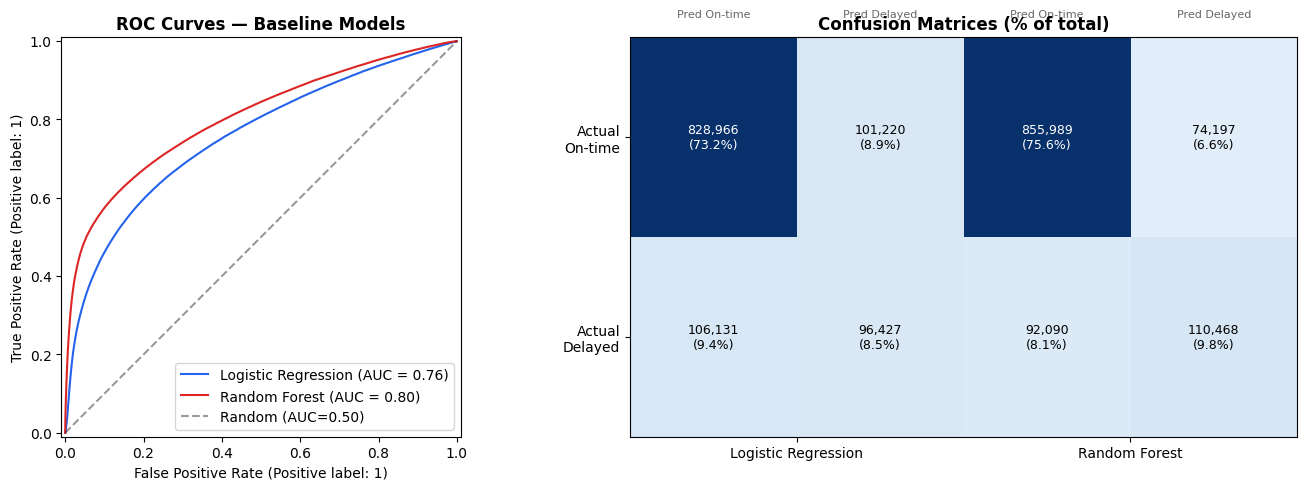

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: ROC curves
ax = axes[0]
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name="Logistic Regression", ax=ax, color="#2563EB")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest", ax=ax, color="#DC2626")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC=0.50)")
ax.set_title("ROC Curves — Baseline Models", fontweight="bold")
ax.legend(loc="lower right")

# Panel B: Confusion matrices side by side
ax = axes[1]
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Normalize for display
cm_combined = np.zeros((2, 4))
cm_combined[:, :2] = cm_lr / cm_lr.sum() * 100
cm_combined[:, 2:] = cm_rf / cm_rf.sum() * 100

im = ax.imshow(cm_combined, cmap="Blues", aspect="auto", vmin=0, vmax=60)
ax.set_xticks([0.5, 2.5])
ax.set_xticklabels(["Logistic Regression", "Random Forest"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["Actual\nOn-time", "Actual\nDelayed"])

for i in range(2):
    for j in range(4):
        col = j % 2
        model_cm = cm_lr if j < 2 else cm_rf
        val = model_cm[i, col]
        pct = val / model_cm.sum() * 100
        ax.text(j, i, f"{val:,}\n({pct:.1f}%)", ha="center", va="center",
                fontsize=9, color="white" if pct > 30 else "black")

ax.set_title("Confusion Matrices (% of total)", fontweight="bold")

# Add pred labels
for offset, label in [(0, "Pred On-time"), (1, "Pred Delayed"), (2, "Pred On-time"), (3, "Pred Delayed")]:
    ax.text(offset, -0.6, label, ha="center", fontsize=8, color="#666")

plt.tight_layout()
plt.savefig(REPORT_DIR / "baseline_roc_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 7: Feature importance (Random Forest)

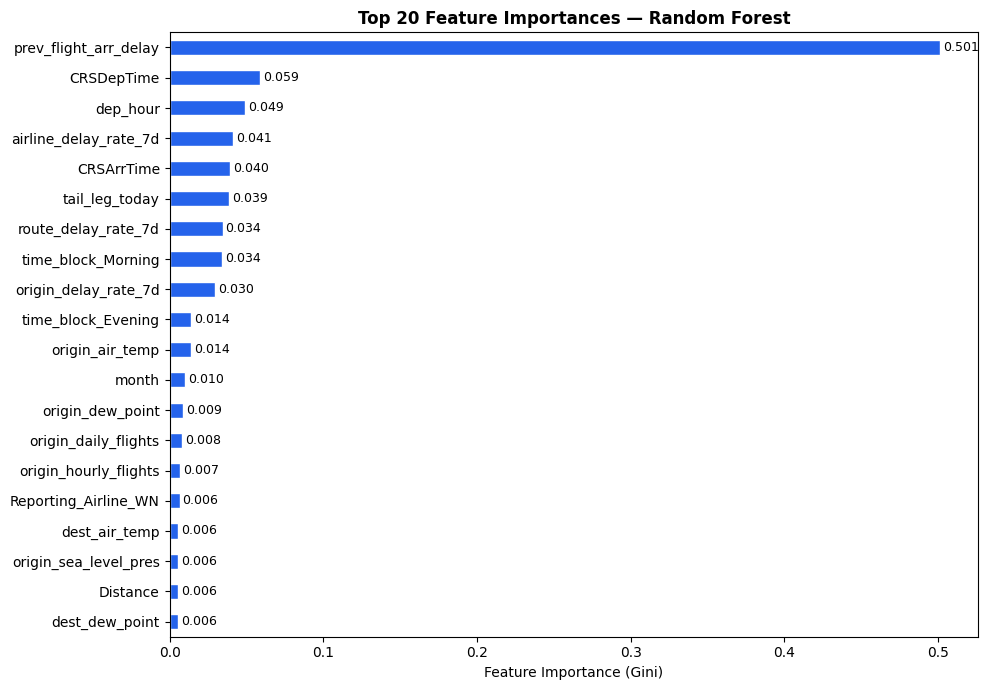

In [11]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20.sort_values().plot.barh(ax=ax, color="#2563EB", edgecolor="white")
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Top 20 Feature Importances — Random Forest", fontweight="bold")

for i, (val, name) in enumerate(zip(top20.sort_values(), top20.sort_values().index)):
    ax.text(val + 0.002, i, f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(REPORT_DIR / "baseline_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8: Summary and next steps

In [12]:
# Final comparison table
print("=" * 75)
print("BASELINE MODEL RESULTS SUMMARY")
print("=" * 75)
print(f"Train set: {len(y_train):,} flights (stratified sample from Jan–Oct 2024)")
print(f"Test set:  {len(y_test):,} flights (Nov–Dec 2024)")
print(f"Features:  {X_train.shape[1]}")
print(f"Class balance: {y_test.mean()*100:.1f}% delayed")
print()
print(results.to_string(index=False, float_format="{:.4f}".format))
print()
print("Top 5 features (Random Forest):")
for i, (feat, imp) in enumerate(importances.nlargest(5).items()):
    print(f"  {i+1}. {feat}: {imp:.4f}")
print("=" * 75)
print()
print("Next steps:")
print("  1. XGBoost / LightGBM for improved non-linear performance")
print("  2. Class imbalance handling (SMOTE / threshold tuning)")
print("  3. Hyperparameter tuning via cross-validation")

BASELINE MODEL RESULTS SUMMARY
Train set: 1,000,000 flights (stratified sample from Jan–Oct 2024)
Test set:  1,132,744 flights (Nov–Dec 2024)
Features:  134
Class balance: 17.9% delayed

                 Model  Accuracy  Precision  Recall     F1  AUC-ROC
Naive (always on-time)    0.8212     0.0000  0.0000 0.0000   0.5000
   Logistic Regression    0.8169     0.4879  0.4760 0.4819   0.7553
         Random Forest    0.8532     0.5982  0.5454 0.5706   0.8039

Top 5 features (Random Forest):
  1. prev_flight_arr_delay: 0.5010
  2. CRSDepTime: 0.0586
  3. dep_hour: 0.0491
  4. airline_delay_rate_7d: 0.0410
  5. CRSArrTime: 0.0395

Next steps:
  1. XGBoost / LightGBM for improved non-linear performance
  2. Class imbalance handling (SMOTE / threshold tuning)
  3. Hyperparameter tuning via cross-validation
